In [34]:
import os

from AI.src.stuffMerger.enums import *
from AI.src.stuffMerger.utils.resources_utility import *
from AI.src.stuffMerger.utils.image_processing_utility import *
import os
if not os.getcwd().endswith("resources"):
    os.chdir("../resources")

In [35]:
"""
_img0: image to match
_img1: image to check
_mask: mask for both images (only check alpha values, can be generated from a black and white image with make_alpha_mask_from_bw)
base_shift: how much the check image is shifted from the first image (can be negative)
check_range: range of offset to check (a, b) a->b (a can be negative)
check_step: how many pixels between each check (1 = every pixel)
direction: change the direction of the shift (0 = horizontal, 1 = vertical)
"""
def find_best_offset(
        _img0: Image.Image,
        _img1: Image.Image,
        _mask: Image.Image,
        base_shift: int,
        check_range: tuple[int, int], # min -> max
        check_step: int,
        direction: Direction = Direction.HORIZONTAL, # 0 = horizontal, 1 = vertical
):
    img0 = np.array(_img0, dtype=np.int32)
    img1 = np.array(_img1, dtype=np.int32)
    mask = np.array(_mask, dtype=np.int32)

    img0 = apply_mask_make_transparent(img0, mask)
    img1 = apply_mask_make_transparent(img1, mask)

    best_score = float("inf")
    best_shift = base_shift

    for delta in range(check_range[0], check_range[1] + 1, check_step):
        shift = base_shift + delta

        # b = np.roll(b, 77, axis=1) 0 = y, 1 = x
        # x positive shift to right, x negative shift to left
        # y positive shift to down, y negative shift to up
        # origin is top left

        if direction == Direction.HORIZONTAL:
            crop1 = np.roll(img1, shift, axis=1)
            crop1[:, :shift] = 0
        else:
            crop1 = np.roll(img1, shift, axis=0)
            crop1[:shift, :] = 0

        score, n_valid = np_absolute_distance_image_comparison(img0, crop1)

        if n_valid == 0:
            continue

        print(f"Score at {delta}: {score!r}")
        if score < best_score:
            best_score = score
            best_shift = shift

    return best_shift, best_score

In [42]:
STEP = 100  # px
TOTAL = 400  # px
CHECK_RANGE = 30  # px
CHECK_FREQUENCY = 1  # px
DIRECTION = Direction.VERTICAL # 0 = horizontal, 1 = vertical
PERFECT = False
CAPTURE = True
ORIENTATION = Orientation.DESCENDING # 0 = descending, 1 = ascending

In [44]:
print(os.getcwd())
if CAPTURE:
    get_image_set(
        perfect = PERFECT,
        vertical = DIRECTION == Direction.VERTICAL,
        orientation = ORIENTATION,
    )

images = [Image.open(f"{'i_' if (not PERFECT) else ''}{'v_' if DIRECTION == Direction.VERTICAL else ''}{'r_' if ORIENTATION == Orientation.ASCENDING else ''}screenshot_{index}.png") for index in range(5)]
ignoreZone = make_alpha_mask_from_bw(Image.open("isandempire_mask.png"))

desk = Image.new("RGBA",
                 (images[0].width+TOTAL+CHECK_RANGE, images[0].height) if DIRECTION == Direction.HORIZONTAL else
                 (images[0].width, images[0].height+TOTAL+CHECK_RANGE),
                 (255, 0, 0, 255)
                 )
desk.paste(
    images[0].convert("RGBA"),
    (0, 0) if ORIENTATION == 0 else (
        (desk.width-images[0].width, 0) if DIRECTION == Direction.HORIZONTAL else (0, desk.height-images[0].height)
    ),
    mask=ignoreZone
)

/home/wip/tesi/BrainyBot/Brain/AI/src/stuffMerger/resources


In [45]:
offsets = []

for i in range(4):
    img0 = images[i].convert("RGB")
    img1 = images[i+1].convert("RGB")
    w0, h0 = img0.size
    w1, h1 = img1.size

    best_shift, best_score = find_best_offset(
        _img0= img0,
        _img1= img1,
        _mask= ignoreZone,
        base_shift = STEP,
        check_range = (-CHECK_RANGE, CHECK_RANGE),
        check_step = CHECK_FREQUENCY,
        direction = DIRECTION
    )
    delta = best_shift - STEP

    print(f"Best shift: {best_shift} px (delta vs STEP: {delta} px), score: {best_score:.4f}")

    offsets.append(best_shift)

Score at -30: 21.961242449850864
Score at -29: 21.882819567797114
Score at -28: 21.804316676341536
Score at -27: 21.72694878775578
Score at -26: 21.64950188549236
Score at -25: 21.5709632001201
Score at -24: 21.31757104585641
Score at -23: 21.062905238846348
Score at -22: 20.807977552985452
Score at -21: 20.553433045333676
Score at -20: 20.298626198643696
Score at -19: 20.078919584768123
Score at -18: 19.912073335678613
Score at -17: 19.745055904438757
Score at -16: 19.577033618491953
Score at -15: 19.408838766745482
Score at -14: 19.240471083214523
Score at -13: 18.764406011384906
Score at -12: 18.18686702011392
Score at -11: 17.608758745237576
Score at -10: 17.03018724852767
Score at -9: 16.45102128841468
Score at -8: 15.857906054791487
Score at -7: 15.218479861515949
Score at -6: 14.57839390200386
Score at -5: 13.940047032119073
Score at -4: 13.301040829348077
Score at -3: 12.661374271649809
Score at -2: 11.078275905590116
Score at -1: 8.86620667503508
Score at 0: 6.651847922633369


In [46]:
print(offsets)

[103, 106, 97, 105]


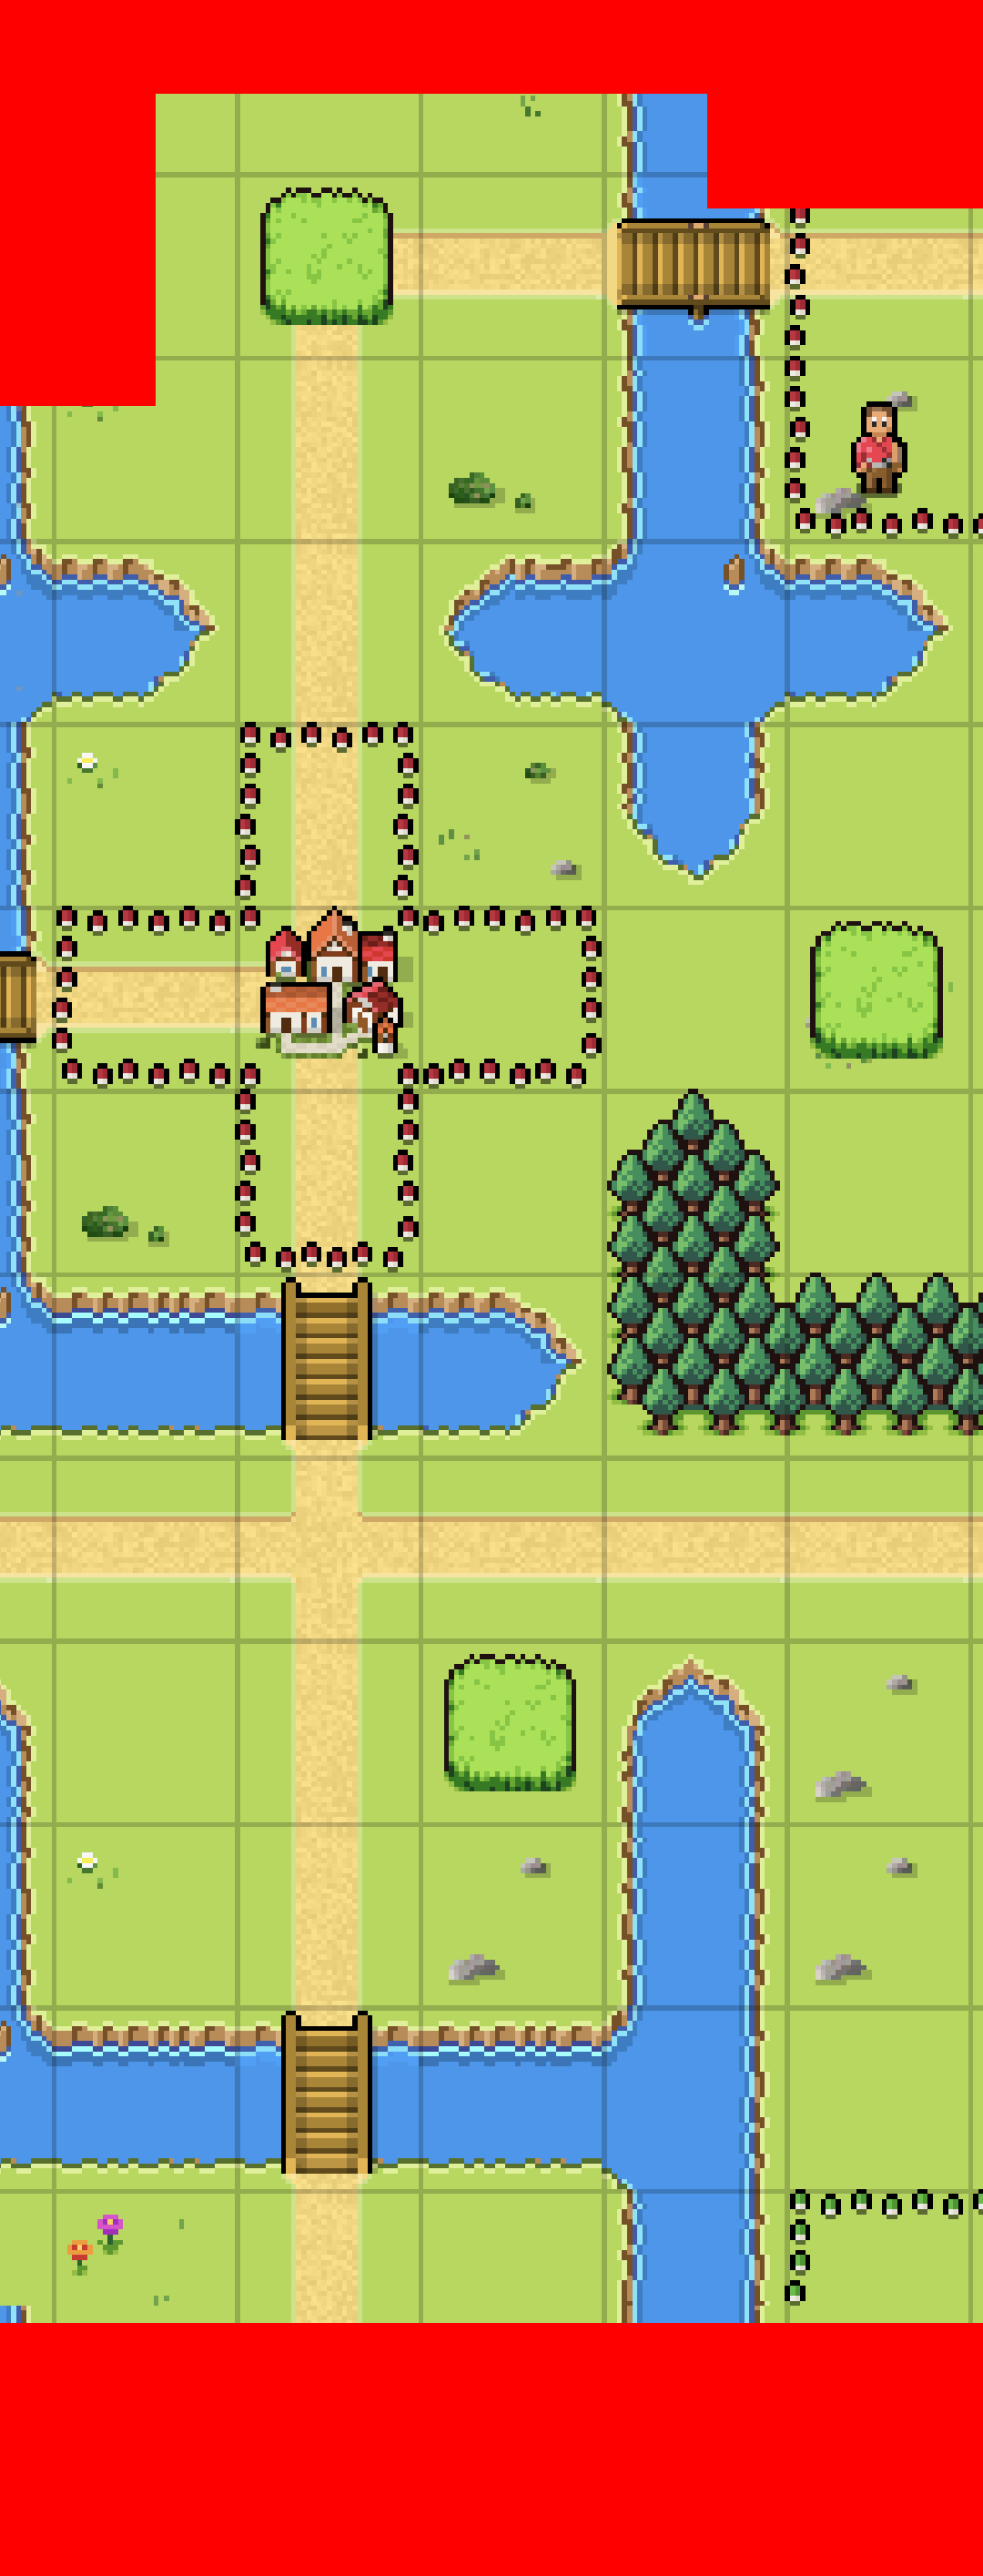

In [47]:
prev_offset = 0
for i in range(4):
    prev_offset+=offsets[i]
    desk.paste(images[i+1],
            (prev_offset, 0) if DIRECTION == Direction.HORIZONTAL else
            (0, prev_offset),
            mask=ignoreZone
        )
desk.show("test")